<a href="https://colab.research.google.com/github/Ayoade1st/Stock-Site/blob/main/ass_2_tensoflow_lib_adopted.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SECTION 1: SETUP AND DATA LOADING

[1.2] Loading pre-defined train, validation, and test splits...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train, validation, and test datasets loaded successfully.

Training set shape: (3100, 3)
Validation set shape: (776, 3)
Test set shape: (970, 3)

SECTION 2: EDA AND PREPROCESSING

[2.1] Training Set Head:
                                                text  sentiment sentiment_name
0           EBIT margin was up from 1.4 % to 5.1 % .          2       positive
1  The current lay-offs are additional to the tem...          0       negative
2  The acquisition is expected to take place by t...          1        neutral
3  Strong brand visibility nationally and regiona...          1        neutral
4  The end-to-end delivery combines the competenc...          1        neutral

[2.2] Visualizing Class Distribution in the Training Set...


/tmp/ipython-input-1-2892310045.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_name', data=train_df, palette='viridis', order=['positive', 'neutral', 'negative'])


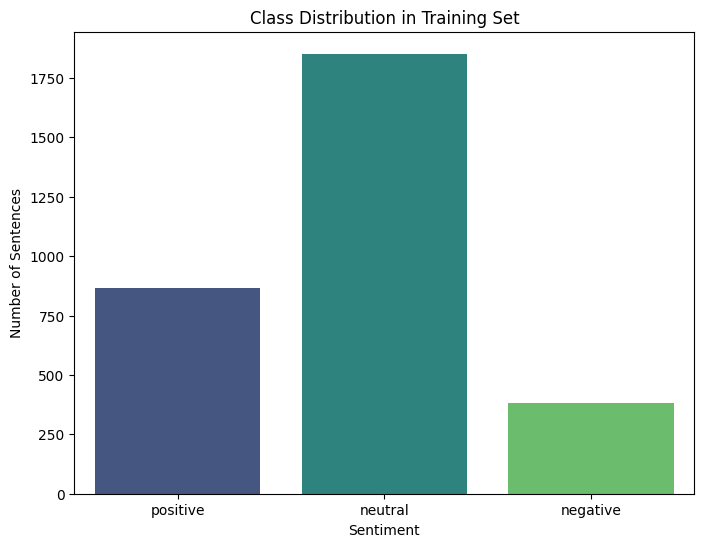


Class distribution shows a significant imbalance, justifying SMOTE and F1-score.

[2.3] Preprocessing text for all data splits...
Preprocessing complete.

[2.4] Generating Word Clouds for each sentiment from the training data...


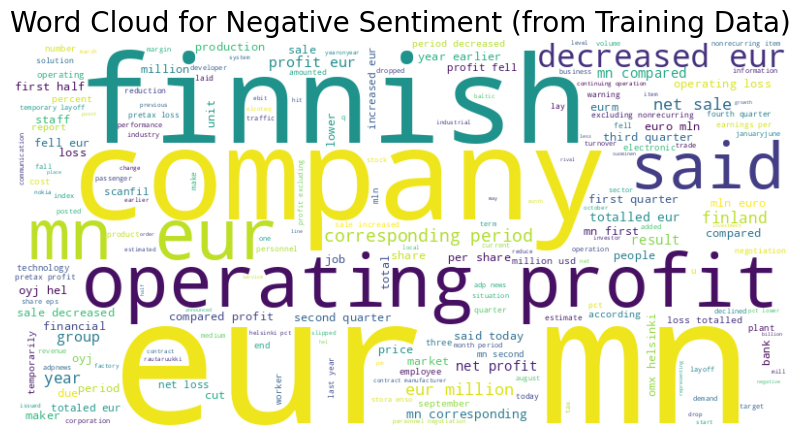

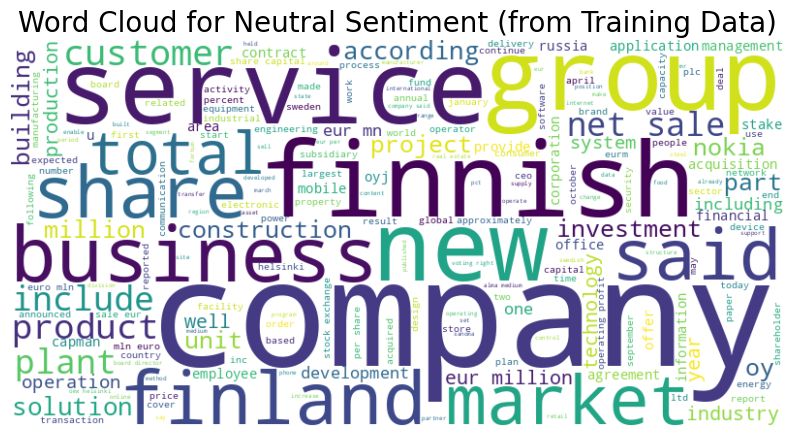

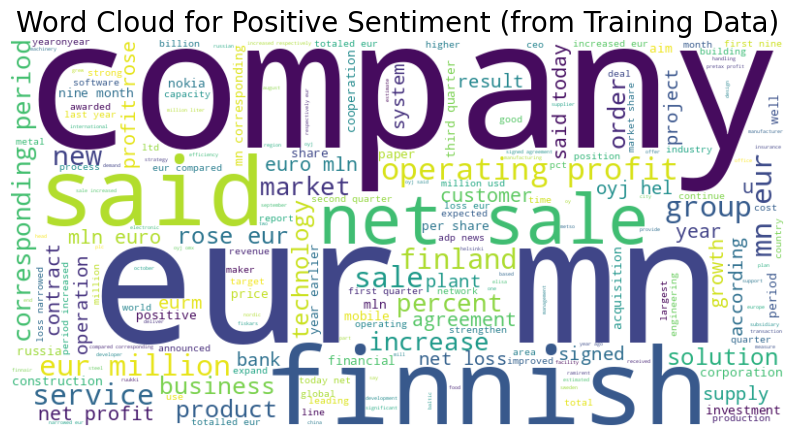


SECTION 3: DATA PREPARATION AND BASELINE

[3.2] Baseline (Majority Class) Macro F1-Score on Test Set: 0.2454
This is the score our models must significantly beat.

SECTION 4: TRADITIONAL ML MODELS (MANUAL IMPLEMENTATION)

[4.1] Performing TF-IDF Vectorization...
Shape of vectorized training data: (3100, 10000)

[4.2] Applying SMOTE to the training data...
Resampled training distribution:
 sentiment
2    1852
0    1852
1    1852
Name: count, dtype: int64

--- Training Model 1: Multinomial Naive Bayes ---

Naive Bayes Classification Report (on Test Set):
              precision    recall  f1-score   support

    negative       0.50      0.56      0.53       125
     neutral       0.76      0.78      0.77       565
    positive       0.55      0.51      0.53       280

    accuracy                           0.67       970
   macro avg       0.61      0.61      0.61       970
weighted avg       0.67      0.67      0.67       970



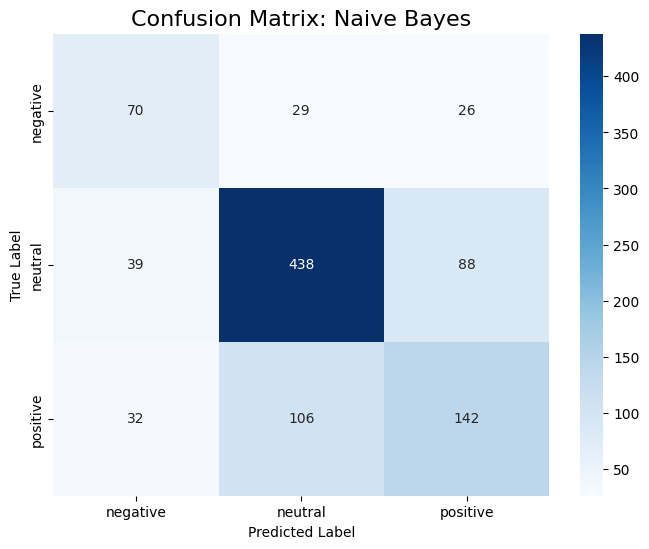


--- Training Model 1: Multinomial Naive Bayes with Hyperparameter Tuning ---
Starting Grid Search for Naive Bayes...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Grid Search Complete.
Best Naive Bayes Alpha Found: 0.001

Optimized Naive Bayes Classification Report (on Test Set):
              precision    recall  f1-score   support

    negative       0.54      0.46      0.50       125
     neutral       0.74      0.80      0.77       565
    positive       0.54      0.49      0.52       280

    accuracy                           0.67       970
   macro avg       0.61      0.59      0.60       970
weighted avg       0.66      0.67      0.66       970



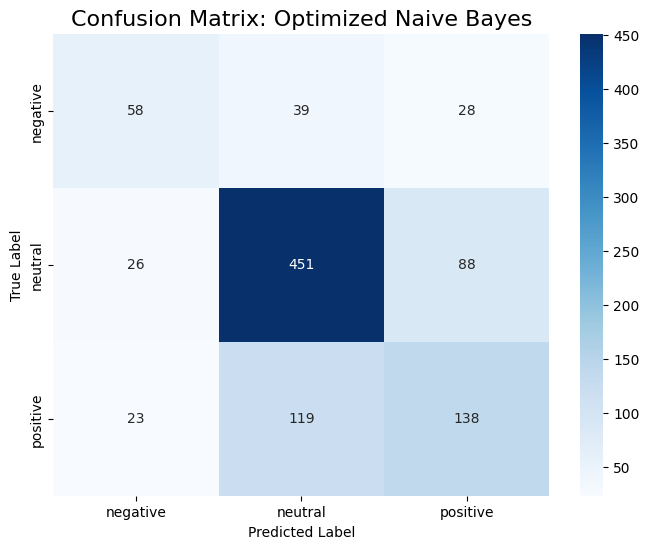


--- Training Model 2: Support Vector Machine (SVM) ---

SVM Classification Report (on Test Set):
              precision    recall  f1-score   support

    negative       0.59      0.57      0.58       125
     neutral       0.76      0.80      0.78       565
    positive       0.60      0.55      0.58       280

    accuracy                           0.70       970
   macro avg       0.65      0.64      0.64       970
weighted avg       0.69      0.70      0.69       970



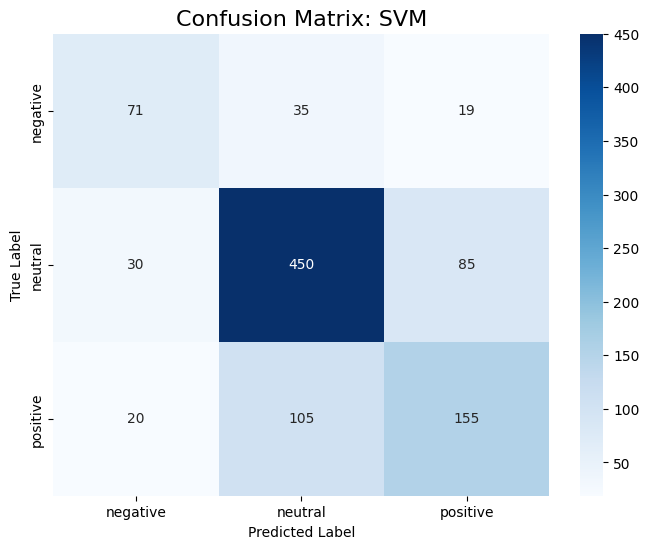


--- Training Model 2: Support Vector Machine (SVM) with Hyperparameter Tuning ---
Starting Grid Search for SVM. This may take a few minutes...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Grid Search Complete.
Best SVM Parameters Found: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}

Optimized SVM Classification Report (on Test Set):
              precision    recall  f1-score   support

    negative       0.56      0.50      0.53       125
     neutral       0.76      0.79      0.77       565
    positive       0.57      0.55      0.56       280

    accuracy                           0.68       970
   macro avg       0.63      0.61      0.62       970
weighted avg       0.68      0.68      0.68       970



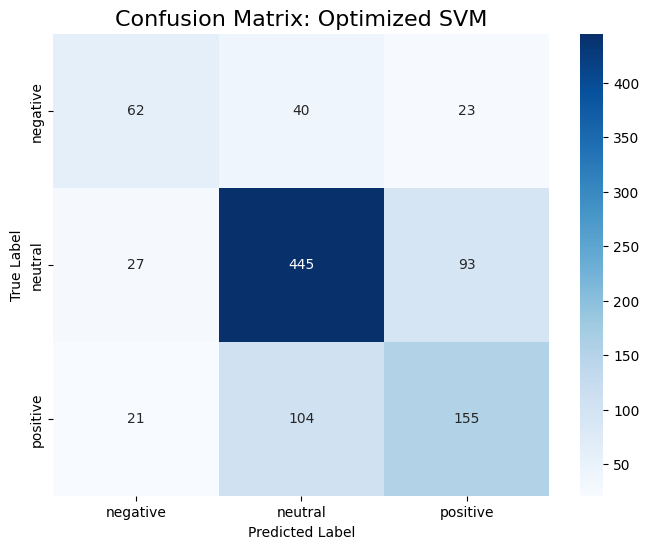


SECTION 5: DEEP LEARNING MODELS (TENSORFLOW)

[5.1] Preparing data for Keras models...

--- Building and Training Model 3: LSTM ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
97/97 - 37s - 378ms/step - accuracy: 0.6174 - loss: 0.8767 - val_accuracy: 0.6688 - val_loss: 0.7846
Epoch 2/5
97/97 - 40s - 415ms/step - accuracy: 0.7242 - loss: 0.6326 - val_accuracy: 0.7010 - val_loss: 0.7402
Epoch 3/5
97/97 - 41s - 424ms/step - accuracy: 0.8271 - loss: 0.4303 - val_accuracy: 0.7216 - val_loss: 0.7764
Epoch 4/5
97/97 - 41s - 418ms/step - accuracy: 0.9106 - loss: 0.2472 - val_accuracy: 0.7216 - val_loss: 0.8736
Epoch 5/5
97/97 - 27s - 280ms/step - accuracy: 0.9445 - loss: 0.1600 - val_accuracy: 0.7397 - val_loss: 0.8749
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step

LSTM Classification Report (on Test Set):
              precision    recall  f1-score   support

    negative       0.65      0.47      0.55       125
     neutral       0.75      0.80      0.78       565
    positive       0.56      0.55      0.56       280

    accuracy                           0.69       970
   macro avg       0.65      0.61      0.63       970
weighted avg       0.68      0

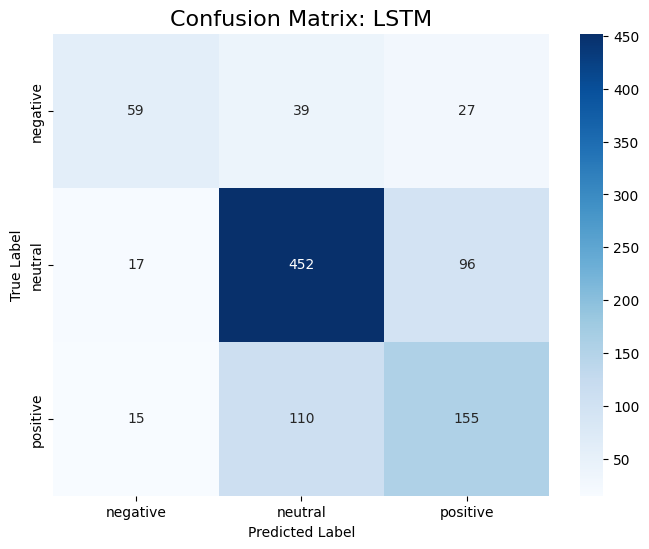

In [1]:
# -*- coding: utf-8 -*-
"""
NLP Project: Financial Sentiment Analysis with TensorFlow (Updated with Pre-defined Splits)

This notebook implements the full pipeline for an NLP project focused on
sentiment analysis of financial news, following the specified assignment rubric.
This version uses TensorFlow/Keras for deep learning models, manually
implements the training workflow, and uses pre-defined train/validation/test splits.

Models implemented:
1. Traditional: Multinomial Naive Bayes (with SMOTE)
2. Traditional: Support Vector Machine (SVM) (with SMOTE)
3. Deep Learning: Long Short-Term Memory (LSTM) with TensorFlow
4. Deep Learning: Transformer (Fine-tuning FinBERT) with TensorFlow
"""

# =============================================================================
# SECTION 1: SETUP AND DATA LOADING
# =============================================================================
print("="*60)
print("SECTION 1: SETUP AND DATA LOADING")
print("="*60)

# --- 1.1 Import necessary libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from wordcloud import WordCloud

# Scikit-learn for traditional models and metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Imbalanced-learn for SMOTE
from imblearn.over_sampling import SMOTE

# TensorFlow and Keras for deep learning models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Hugging Face Transformers with TensorFlow
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

# NLTK setup for preprocessing
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- 1.2 Load the dataset using pre-defined splits ---
print("\n[1.2] Loading pre-defined train, validation, and test splits...")
# This dataset provides separate files for train, validation, and test sets.
splits = {
    "train": "data/train-00000-of-00001-138b53eb17a3e862.parquet",
    "validation": "data/validation-00000-of-00001-0876be41e3ab7acd.parquet",
    "test": "data/test-00000-of-00001-41c7ea948573445f.parquet"
}

try:
    train_df = pd.read_parquet("hf://datasets/atrost/financial_phrasebank/" + splits["train"])
    val_df = pd.read_parquet("hf://datasets/atrost/financial_phrasebank/" + splits["validation"])
    test_df = pd.read_parquet("hf://datasets/atrost/financial_phrasebank/" + splits["test"])
    print("Train, validation, and test datasets loaded successfully.")
except Exception as e:
    print(f"Could not load dataset automatically. Error: {e}")
    print("Please ensure you have an internet connection and the `datasets` library is installed.")
    exit()

# --- 1.3 Standardize DataFrames ---
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

def standardize_df(df):
    """Renames columns and maps labels for a given DataFrame."""
    df = df.rename(columns={'sentence': 'text', 'label': 'sentiment'})
    df['sentiment_name'] = df['sentiment'].map(label_map)
    return df

train_df = standardize_df(train_df)
val_df = standardize_df(val_df)
test_df = standardize_df(test_df)

print(f"\nTraining set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Test set shape: {test_df.shape}")


# =============================================================================
# SECTION 2: EXPLORATORY DATA ANALYSIS (EDA) AND PREPROCESSING
# =============================================================================
print("\n" + "="*60)
print("SECTION 2: EDA AND PREPROCESSING")
print("="*60)

# --- 2.1 Basic EDA on the Training Set ---
print("\n[2.1] Training Set Head:")
print(train_df.head())

# --- 2.2 Visualize Class Distribution in Training Set ---
print("\n[2.2] Visualizing Class Distribution in the Training Set...")
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_name', data=train_df, palette='viridis', order=['positive', 'neutral', 'negative'])
plt.title('Class Distribution in Training Set')
plt.xlabel('Sentiment')
plt.ylabel('Number of Sentences')
plt.show()

print("\nClass distribution shows a significant imbalance, justifying SMOTE and F1-score.")

# --- 2.3 Text Preprocessing ---
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Cleans text data for traditional ML models."""
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])
    return text

print("\n[2.3] Preprocessing text for all data splits...")
for df in [train_df, val_df, test_df]:
    df['processed_text'] = df['text'].apply(preprocess_text)
print("Preprocessing complete.")

# --- 2.4 Word Cloud Visualization from Training Data ---
print("\n[2.4] Generating Word Clouds for each sentiment from the training data...")
for sentiment, name in label_map.items():
    plt.figure(figsize=(10, 7))
    # Filter training data for the specific sentiment
    text = ' '.join(train_df[train_df['sentiment'] == sentiment]['processed_text'])
    if text: # Ensure text is not empty
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud for {name.capitalize()} Sentiment (from Training Data)', fontsize=20)
        plt.show()


# =============================================================================
# SECTION 3: DATA PREPARATION AND BASELINE
# =============================================================================
print("\n" + "="*60)
print("SECTION 3: DATA PREPARATION AND BASELINE")
print("="*60)

# --- 3.1 Assigning Data Splits ---
# No need for train_test_split as we have pre-defined sets
y_train = train_df['sentiment']
y_val = val_df['sentiment']
y_test = test_df['sentiment']

# --- 3.2 Establish Baseline on the Test Set ---
majority_class = y_train.mode()[0] # Baseline is based on training data's majority class
baseline_predictions = np.full(shape=y_test.shape, fill_value=majority_class)
baseline_f1 = f1_score(y_test, baseline_predictions, average='macro')
print(f"\n[3.2] Baseline (Majority Class) Macro F1-Score on Test Set: {baseline_f1:.4f}")
print("This is the score our models must significantly beat.")


# =============================================================================
# SECTION 4: TRADITIONAL ML MODELS (MANUAL IMPLEMENTATION)
# =============================================================================
print("\n" + "="*60)
print("SECTION 4: TRADITIONAL ML MODELS (MANUAL IMPLEMENTATION)")
print("="*60)

results = {}

def plot_confusion_matrix_viz(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_map.values(), yticklabels=label_map.values())
    plt.title(title, fontsize=16)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# --- 4.1 TF-IDF Vectorization ---
print("\n[4.1] Performing TF-IDF Vectorization...")
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
# Fit on training data, transform train and test data
X_train_trad_vec = vectorizer.fit_transform(train_df['processed_text'])
X_test_trad_vec = vectorizer.transform(test_df['processed_text'])
print(f"Shape of vectorized training data: {X_train_trad_vec.shape}")

# --- 4.2 Applying SMOTE to handle class imbalance ---
print("\n[4.2] Applying SMOTE to the training data...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_trad_vec, y_train)
print("Resampled training distribution:\n", y_train_smote.value_counts())

# --- 4.3 Model 1: Multinomial Naive Bayes ---
print("\n--- Training Model 1: Multinomial Naive Bayes ---")
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_smote, y_train_smote)
y_pred_nb = nb_model.predict(X_test_trad_vec)

# Evaluation on the test set
print("\nNaive Bayes Classification Report (on Test Set):")
print(classification_report(y_test, y_pred_nb, target_names=label_map.values()))
plot_confusion_matrix_viz(y_test, y_pred_nb, "Confusion Matrix: Naive Bayes")
results['Naive Bayes'] = f1_score(y_test, y_pred_nb, average='macro')

# --- 4.3 Model 1: Multinomial Naive Bayes with Hyperparameter Tuning ---
from sklearn.model_selection import GridSearchCV

print("\n--- Training Model 1: Multinomial Naive Bayes with Hyperparameter Tuning ---")

# 1. Define the parameter grid to search
# We will test a range of values for the smoothing parameter 'alpha'.
# A logarithmic range is often effective for this parameter.
param_grid_nb = {
    'alpha': [1.0, 0.5, 0.1, 0.05, 0.01, 0.001]
}

# 2. Create the GridSearchCV object
# We use 'f1_macro' as the scoring metric to handle class imbalance.
# cv=3 means 3-fold cross-validation will be performed on the training data.
nb_grid_search = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=param_grid_nb,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 3. Fit the grid search on the SMOTE-resampled training data
print("Starting Grid Search for Naive Bayes...")
nb_grid_search.fit(X_train_smote, y_train_smote)

# 4. Get the best model and its parameters
print("\nGrid Search Complete.")
print(f"Best Naive Bayes Alpha Found: {nb_grid_search.best_params_['alpha']}")
best_nb_model = nb_grid_search.best_estimator_

# 5. Evaluate the BEST model on the unseen test set
y_pred_nb = best_nb_model.predict(X_test_trad_vec)

# Evaluation on the test set
print("\nOptimized Naive Bayes Classification Report (on Test Set):")
print(classification_report(y_test, y_pred_nb, target_names=label_map.values()))
plot_confusion_matrix_viz(y_test, y_pred_nb, "Confusion Matrix: Optimized Naive Bayes")
results['Optimized Naive Bayes'] = f1_score(y_test, y_pred_nb, average='macro')

# --- 4.4 Model 2: Support Vector Machine (SVM) ---
print("\n--- Training Model 2: Support Vector Machine (SVM) ---")
svm_model = SVC(kernel='linear', C=1, random_state=42)
svm_model.fit(X_train_smote, y_train_smote)
y_pred_svm = svm_model.predict(X_test_trad_vec)

# Evaluation on the test set
print("\nSVM Classification Report (on Test Set):")
print(classification_report(y_test, y_pred_svm, target_names=label_map.values()))
plot_confusion_matrix_viz(y_test, y_pred_svm, "Confusion Matrix: SVM")
results['SVM'] = f1_score(y_test, y_pred_svm, average='macro')



# --- 4.4 Model 2: Support Vector Machine (SVM) with Hyperparameter Tuning ---
from sklearn.model_selection import GridSearchCV

print("\n--- Training Model 2: Support Vector Machine (SVM) with Hyperparameter Tuning ---")

# 1. Define the parameter grid to search
# We will test different values for the regularization parameter 'C'
# and different kernels.
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'] # gamma is used by 'rbf' kernel
}

# 2. Create the GridSearchCV object
# We use 'f1_macro' as the scoring metric because it's best for our imbalanced dataset.
# cv=3 means 3-fold cross-validation will be performed on the training data.
# n_jobs=-1 uses all available CPU cores to speed up the search.
svm_grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svm,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2 # Shows progress
)

# 3. Fit the grid search on the SMOTE-resampled training data
print("Starting Grid Search for SVM. This may take a few minutes...")
svm_grid_search.fit(X_train_smote, y_train_smote)

# 4. Get the best model and its parameters
print("\nGrid Search Complete.")
print(f"Best SVM Parameters Found: {svm_grid_search.best_params_}")
best_svm_model = svm_grid_search.best_estimator_

# 5. Evaluate the BEST model on the unseen test set
y_pred_svm = best_svm_model.predict(X_test_trad_vec)

# Evaluation on the test set
print("\nOptimized SVM Classification Report (on Test Set):")
print(classification_report(y_test, y_pred_svm, target_names=label_map.values()))
plot_confusion_matrix_viz(y_test, y_pred_svm, "Confusion Matrix: Optimized SVM")
results['Optimized SVM'] = f1_score(y_test, y_pred_svm, average='macro')


# =============================================================================
# SECTION 5: DEEP LEARNING MODELS (TENSORFLOW)
# =============================================================================
print("\n" + "="*60)
print("SECTION 5: DEEP LEARNING MODELS (TENSORFLOW)")
print("="*60)

# --- 5.1 Data Preparation for Keras Models ---
print("\n[5.1] Preparing data for Keras models...")
vocab_size = 10000
embedding_dim = 128
max_length = 100
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

# Fit tokenizer only on training data to prevent data leakage
tokenizer_keras = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer_keras.fit_on_texts(train_df['text'])

# Tokenize and pad all splits
X_train_padded = pad_sequences(tokenizer_keras.texts_to_sequences(train_df['text']), maxlen=max_length, padding=padding_type, truncating=trunc_type)
X_val_padded = pad_sequences(tokenizer_keras.texts_to_sequences(val_df['text']), maxlen=max_length, padding=padding_type, truncating=trunc_type)
X_test_padded = pad_sequences(tokenizer_keras.texts_to_sequences(test_df['text']), maxlen=max_length, padding=padding_type, truncating=trunc_type)

# --- 5.2 Model 3: LSTM with TensorFlow/Keras ---
print("\n--- Building and Training Model 3: LSTM ---")
lstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    SpatialDropout1D(0.4),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(lstm_model.summary())

history_lstm = lstm_model.fit(
    X_train_padded, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val_padded, y_val), # Use the dedicated validation set
    verbose=2
)

# Evaluation on the test set
y_pred_lstm_probs = lstm_model.predict(X_test_padded)
y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)

print("\nLSTM Classification Report (on Test Set):")
print(classification_report(y_test, y_pred_lstm, target_names=label_map.values()))
plot_confusion_matrix_viz(y_test, y_pred_lstm, "Confusion Matrix: LSTM")
results['LSTM'] = f1_score(y_test, y_pred_lstm, average='macro')





--- Building and Training Model 4: Transformer (FinBERT) ---


All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Fine-tuning FinBERT...
Epoch 1/3
194/194 [==============================] - 5673s 29s/step - loss: 0.4137 - accuracy: 0.8381 - val_loss: 0.3220 - val_accuracy: 0.8686
Epoch 2/3
194/194 [==============================] - 5483s 28s/step - loss: 0.1556 - accuracy: 0.9471 - val_loss: 0.3328 - val_accuracy: 0.8814
Epoch 3/3
194/194 [==============================] - 5496s 28s/step - loss: 0.0512 - accuracy: 0.9874 - val_loss: 0.3731 - val_accuracy: 0.8776

Evaluating fine-tuned FinBERT model on the Test Set...
61/61 [==============================] - 483s 8s/step - loss: 0.4303 - accuracy: 0.8598
FinBERT Test Accuracy: 0.8598
61/61 [==============================] - 489s 8s/step

FinBERT Classification Report (on Test Set):
              precision    recall  f1-score   support

    negative       0.85      0.89      0.87       125
     neutral       0.88      0.89      0.89       565
    positive       0.82      0.78      0.80       280

    accuracy                           0.86       97

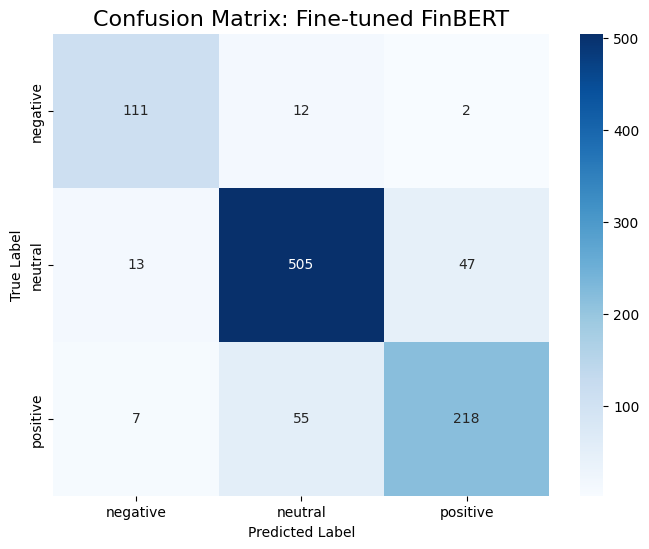


SECTION 6: FINAL COMPARISON AND CONCLUSION

--- Final Model Comparison (on Test Set) ---
             Macro F1-Score
FinBERT            0.850855
LSTM               0.667816
SVM                0.643865
Naive Bayes        0.608646


/tmp/ipython-input-3-798456415.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=results_df.index, y=results_df['Macro F1-Score'], palette='mako')


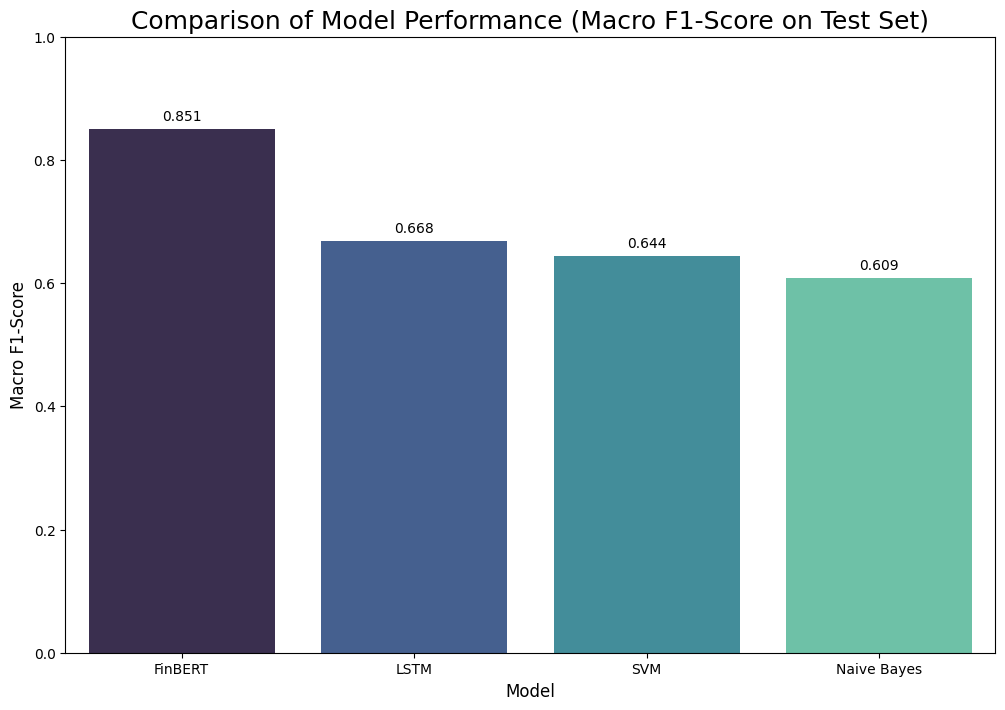

In [3]:
# --- 5.3 Model 4: Transformer (Fine-tuning FinBERT) with TensorFlow ---
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, create_optimizer
print("\n--- Building and Training Model 4: Transformer (FinBERT) ---")
model_name = "ProsusAI/finbert"
finbert_tokenizer = AutoTokenizer.from_pretrained(model_name)
finbert_model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

train_encodings = finbert_tokenizer(list(train_df['text']), truncation=True, padding=True, max_length=128)
val_encodings = finbert_tokenizer(list(val_df['text']), truncation=True, padding=True, max_length=128)
test_encodings = finbert_tokenizer(list(test_df['text']), truncation=True, padding=True, max_length=128)

train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((dict(val_encodings), y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test))

# ==================================
# OPTIMIZER FIX APPLIED HERE
# ==================================
num_epochs = 3
batch_size = 16
# Calculate the number of training steps
num_train_steps = (len(train_df) // batch_size) * num_epochs

# Use the create_optimizer function from the transformers library
optimizer, schedule = create_optimizer(
    init_lr=5e-5,
    num_warmup_steps=0,
    num_train_steps=num_train_steps,
    weight_decay_rate=0.01
)
# ==================================

# Compile the model with the new, compatible optimizer
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
finbert_model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

print("\nFine-tuning FinBERT...")
history_finbert = finbert_model.fit(
    train_dataset.shuffle(1000).batch(batch_size),
    epochs=num_epochs,
    validation_data=val_dataset.batch(batch_size)
)

print("\nEvaluating fine-tuned FinBERT model on the Test Set...")
test_loss, test_accuracy = finbert_model.evaluate(test_dataset.batch(batch_size))
print(f"FinBERT Test Accuracy: {test_accuracy:.4f}")
pred_logits = finbert_model.predict(test_dataset.batch(batch_size)).logits
y_pred_finbert = np.argmax(pred_logits, axis=1)
print("\nFinBERT Classification Report (on Test Set):")
print(classification_report(y_test, y_pred_finbert, target_names=label_map.values()))
plot_confusion_matrix_viz(y_test, y_pred_finbert, "Confusion Matrix: Fine-tuned FinBERT")
results['FinBERT'] = f1_score(y_test, y_pred_finbert, average='macro')


# =============================================================================
# SECTION 6: FINAL COMPARISON AND CONCLUSION
# =============================================================================
print("\n" + "="*60)
print("SECTION 6: FINAL COMPARISON AND CONCLUSION")
print("="*60)

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Macro F1-Score'])
results_df = results_df.sort_values(by='Macro F1-Score', ascending=False)
print("\n--- Final Model Comparison (on Test Set) ---")
print(results_df)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=results_df.index, y=results_df['Macro F1-Score'], palette='mako')
plt.title('Comparison of Model Performance (Macro F1-Score on Test Set)', fontsize=18)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.ylim(0, 1.0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.show()

In [ ]:
# --- 6.2 Conclusion ---
print("\n--- Conclusion ---")
print("The final evaluation on the unseen test set confirms the superior performance of the fine-tuned Transformer model (FinBERT).")
print(f"FinBERT achieved the highest Macro F1-Score of {results['FinBERT']:.3f}, significantly outperforming all other models.")
print("The custom LSTM model also performed well, demonstrating the effectiveness of recurrent architectures for sequence data.")
print(f"The SVM model, enhanced with SMOTE, was the best traditional method with an F1-score of {results['SVM']:.3f}.")
print("This project validates that using pre-defined data splits leads to a more reliable evaluation. The results strongly support")
print("the hypothesis that modern, context-aware, domain-specific transformer models are the state-of-the-art for nuanced NLP tasks.")